In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_auc_score, roc_curve,
                              precision_recall_curve, f1_score)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
data = pd.read_csv("health care diabetes.csv")
print("Shape:", data.shape)
data.head(10)

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0,118,83,19,147,30.9,0.311,21,0
1,4,146,89,20,163,28.1,0.259,35,1
2,0,164,80,27,147,49.8,0.376,21,1
3,5,139,59,4,39,36.5,0.363,63,1
4,0,89,26,23,0,26.2,0.347,22,0
5,11,169,99,6,256,38.7,0.837,48,1
6,0,98,83,0,218,34.5,0.415,33,0
7,0,100,88,38,335,29.7,0.232,25,0
8,0,107,75,19,177,28.5,0.325,24,0
9,0,96,45,45,224,45.1,0.078,21,1


In [5]:
data.info()

data.describe().transpose().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.53,2.93,0.00,1.00,3.00,5.00,14.00
Glucose,768.0,121.28,29.58,42.00,101.00,121.00,139.00,199.00
BloodPressure,768.0,67.02,18.97,10.00,54.00,68.00,81.00,121.00
SkinThickness,768.0,20.36,14.22,0.00,9.00,19.00,30.00,69.00
Insulin,768.0,95.89,93.31,0.00,1.75,77.00,153.25,627.00
BMI,768.0,31.44,8.04,4.20,26.18,31.20,36.42,56.60
DiabetesPedigreeFunction,768.0,0.49,0.30,0.08,0.25,0.47,0.68,1.55
Age,768.0,33.90,10.17,21.00,25.00,33.00,41.00,66.00
Outcome,768.0,0.35,0.48,0.00,0.00,0.00,1.00,1.00


In [6]:
# Check class distribution
print("Outcome Distribution:")
print(data['Outcome'].value_counts())
print()
print(f"Non-Diabetic (0): {(data['Outcome']==0).sum()} patients ({(data['Outcome']==0).mean()*100:.1f}%)")
print(f"Diabetic     (1): {(data['Outcome']==1).sum()} patients ({(data['Outcome']==1).mean()*100:.1f}%)")

Outcome Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Non-Diabetic (0): 500 patients (65.1%)
Diabetic     (1): 268 patients (34.9%)


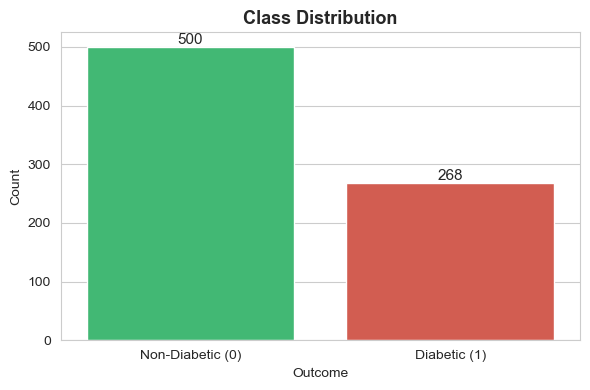

In [7]:
# Visualize class distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Outcome', data=data, palette=['#2ecc71', '#e74c3c'])
ax.set_xticklabels(['Non-Diabetic (0)', 'Diabetic (1)'])
plt.title('Class Distribution', fontsize=13, fontweight='bold')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()+5),
                ha='center', fontsize=11)
plt.tight_layout()
plt.show()

In [8]:
# Check how many zeros exist in medical columns
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Zero counts BEFORE cleaning:")
for col in cols_with_zeros:
    zeros = (data[col] == 0).sum()
    pct   = zeros / len(data) * 100
    print(f"  {col:<25}: {zeros} zeros ({pct:.1f}%)")

Zero counts BEFORE cleaning:
  Glucose                  : 0 zeros (0.0%)
  BloodPressure            : 0 zeros (0.0%)
  SkinThickness            : 72 zeros (9.4%)
  Insulin                  : 189 zeros (24.6%)
  BMI                      : 0 zeros (0.0%)


In [9]:
# Replace zeros with median of that column
for col in cols_with_zeros:
    median_val = data[col].replace(0, np.nan).median()
    data[col]  = data[col].replace(0, median_val)

print("Zero counts AFTER cleaning:")
for col in cols_with_zeros:
    print(f"  {col:<25}: {(data[col] == 0).sum()} zeros")

print()
print("Updated statistics after cleaning:")
data[cols_with_zeros].describe().transpose().round(2)

Zero counts AFTER cleaning:
  Glucose                  : 0 zeros
  BloodPressure            : 0 zeros
  SkinThickness            : 0 zeros
  Insulin                  : 0 zeros
  BMI                      : 0 zeros

Updated statistics after cleaning:


,count,mean,std,min,25%,50%,75%,max
Glucose,768.0,121.28,29.58,42.0,101.00,121.0,139.00,199.0
BloodPressure,768.0,67.02,18.97,10.0,54.00,68.0,81.00,121.0
SkinThickness,768.0,22.33,12.63,1.0,13.00,21.0,30.00,69.0
Insulin,768.0,123.21,75.83,1.0,76.75,111.0,153.25,627.0
BMI,768.0,31.44,8.04,4.2,26.18,31.2,36.42,56.6


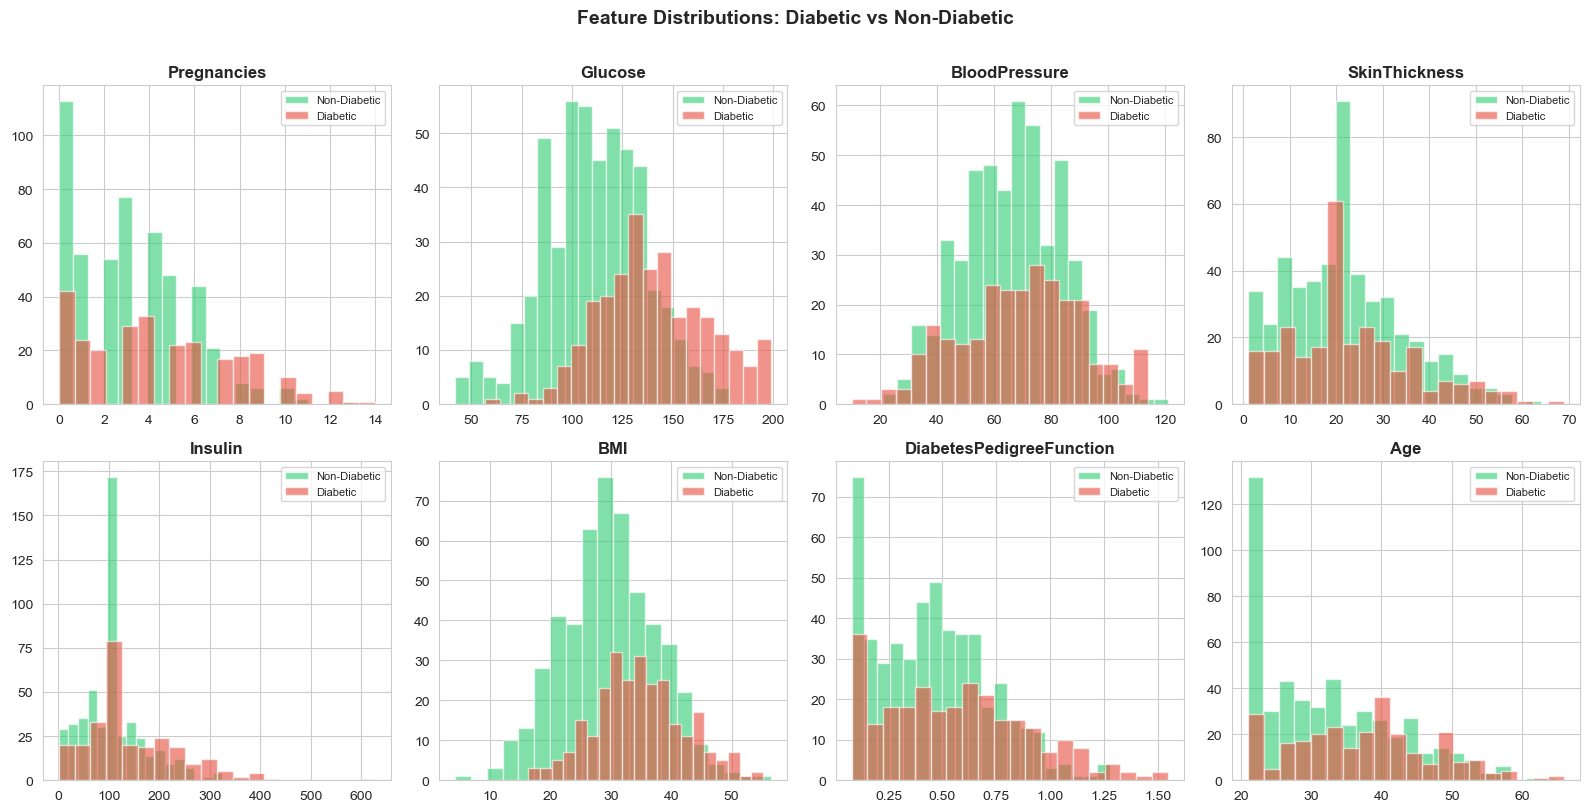

In [10]:
# 5) Performed EDA
# Distribution of all features — separated by Outcome
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
features_list = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
                 'Insulin','BMI','DiabetesPedigreeFunction','Age']

for i, col in enumerate(features_list):
    axes[i].hist(data[data['Outcome']==0][col], bins=20, alpha=0.6, color='#2ecc71', label='Non-Diabetic')
    axes[i].hist(data[data['Outcome']==1][col], bins=20, alpha=0.6, color='#e74c3c', label='Diabetic')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions: Diabetic vs Non-Diabetic', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

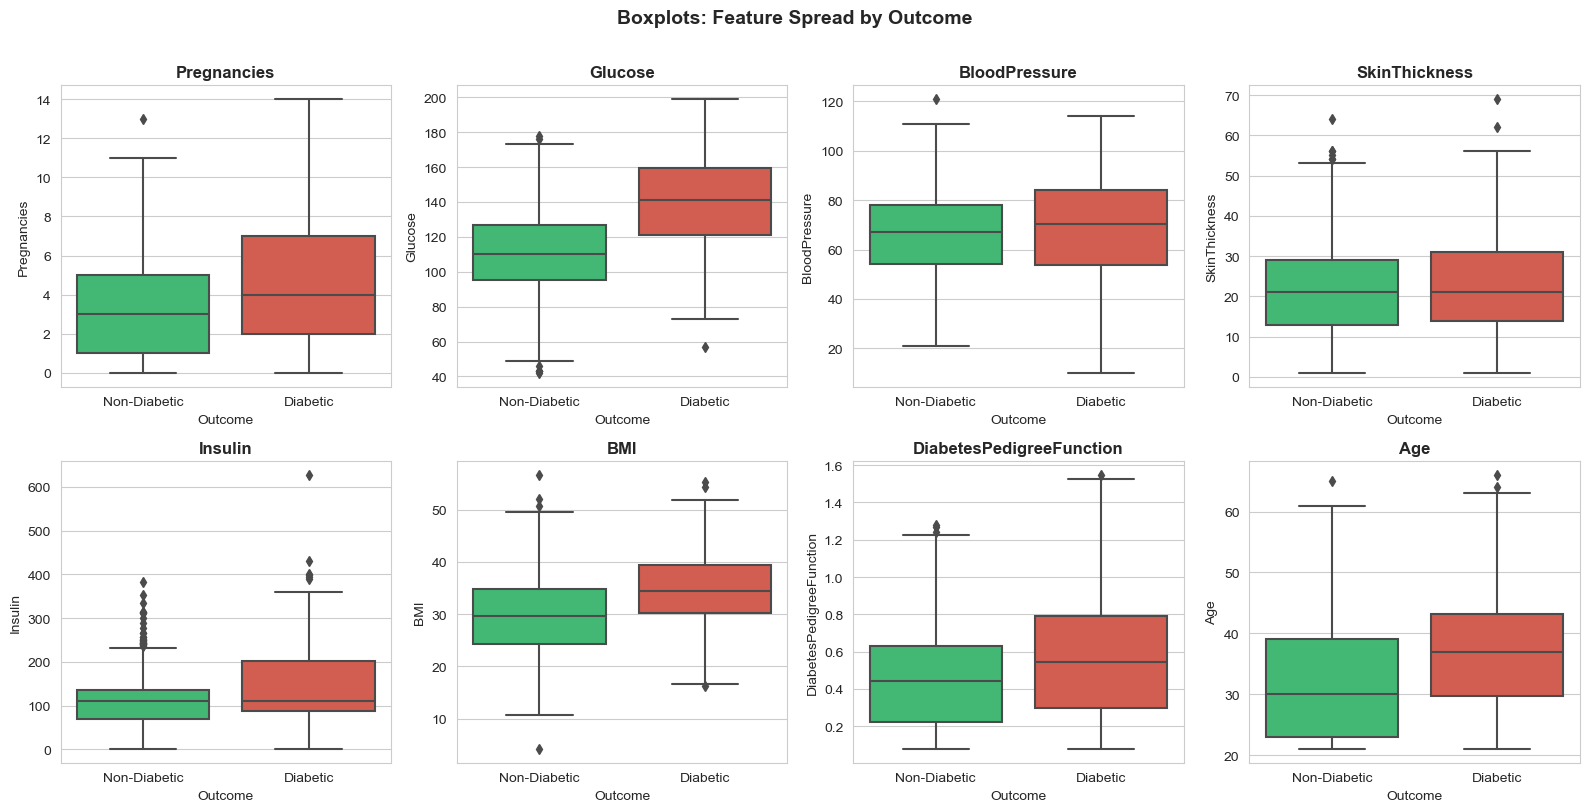

In [11]:
#Boxplots to see spread and outliers per class
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features_list):
    sns.boxplot(x='Outcome', y=col, data=data,
                palette=['#2ecc71','#e74c3c'], ax=axes[i])
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xticklabels(['Non-Diabetic','Diabetic'])

plt.suptitle('Boxplots: Feature Spread by Outcome', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

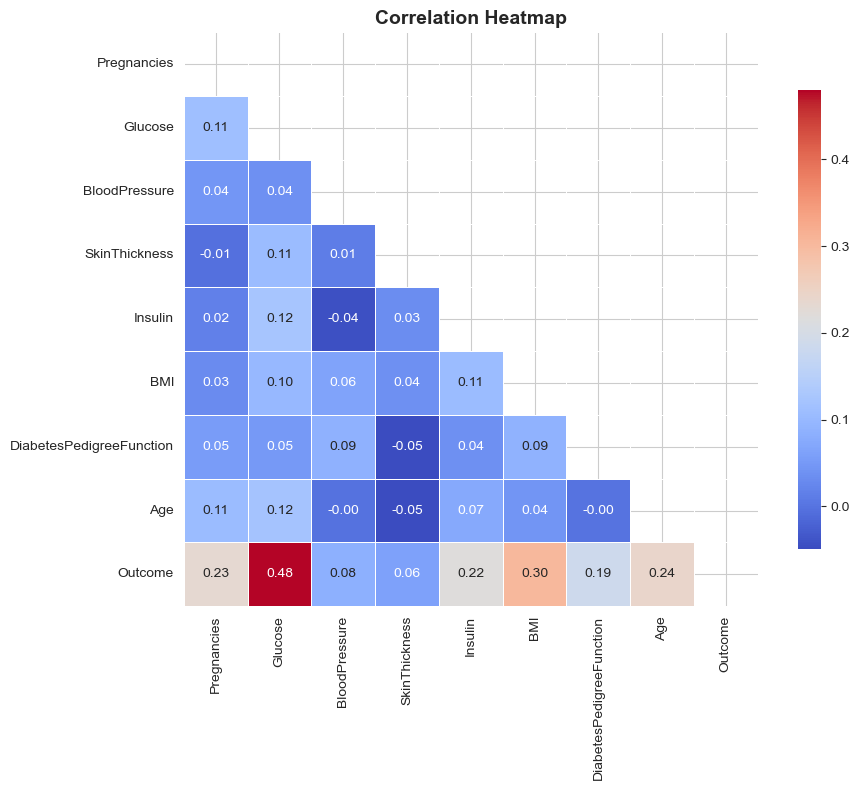


Top correlations with Outcome (Diabetes):
Glucose                     0.480
BMI                         0.304
Age                         0.241
Pregnancies                 0.233
Insulin                     0.218
DiabetesPedigreeFunction    0.185
BloodPressure               0.084
SkinThickness               0.061


In [12]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop correlations with Outcome (Diabetes):")
print(corr['Outcome'].drop('Outcome').sort_values(ascending=False).round(3).to_string())

In [13]:
# Average values: Diabetic vs Non-Diabetic
comparison = data.groupby('Outcome')[features_list].mean().round(2).T
comparison.columns = ['Non-Diabetic (0)', 'Diabetic (1)']
comparison['Difference'] = (comparison['Diabetic (1)'] - comparison['Non-Diabetic (0)']).round(2)
print("Average Feature Values — Diabetic vs Non-Diabetic:")
print(comparison.to_string())

Average Feature Values — Diabetic vs Non-Diabetic:
                          Non-Diabetic (0)  Diabetic (1)  Difference
Pregnancies                           3.03          4.46        1.43
Glucose                             110.88        140.67       29.79
BloodPressure                        65.85         69.21        3.36
SkinThickness                        21.76         23.38        1.62
Insulin                             111.10        145.81       34.71
BMI                                  29.65         34.78        5.13
DiabetesPedigreeFunction              0.45          0.57        0.12
Age                                  32.11         37.25        5.14


In [14]:
# Prepared feature Scaling 
# Separate features and label
X = data[features_list].values
y = data['Outcome'].values

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size : {X_train.shape}")
print(f"Testing set size  : {X_test.shape}")
print(f"\nClass balance in training set:")
print(f"  Non-Diabetic: {(y_train==0).sum()} | Diabetic: {(y_train==1).sum()}")
print(f"Class balance in test set:")
print(f"  Non-Diabetic: {(y_test==0).sum()} | Diabetic: {(y_test==1).sum()}")

Training set size : (614, 8)
Testing set size  : (154, 8)

Class balance in training set:
  Non-Diabetic: 400 | Diabetic: 214
Class balance in test set:
  Non-Diabetic: 100 | Diabetic: 54


In [15]:
# Apply StandardScaler — fit on train, transform both
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Feature scaling applied successfully!")
print("Mean of scaled training data (should be ~0):", X_train.mean(axis=0).round(3))

Feature scaling applied successfully!
Mean of scaled training data (should be ~0): [-0.  0.  0. -0. -0. -0.  0. -0.]


In [17]:
# Training Machine Learning Models

In [18]:
# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
print("Logistic Regression — Train:", round(lr.score(X_train, y_train), 4),
      "| Test:", round(lr.score(X_test, y_test), 4))

Logistic Regression — Train: 0.8111 | Test: 0.8052


In [19]:
# 2. Decision Tree — max_depth=5 to prevent overfitting (FIX 3)
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
print("Decision Tree     — Train:", round(dt.score(X_train, y_train), 4),
      "| Test:", round(dt.score(X_test, y_test), 4))

Decision Tree     — Train: 0.8453 | Test: 0.7532


In [20]:
# 3. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("Random Forest     — Train:", round(rf.score(X_train, y_train), 4),
      "| Test:", round(rf.score(X_test, y_test), 4))

Random Forest     — Train: 1.0 | Test: 0.7987


In [21]:
# 4. SVM — benefits greatly from scaling
svm = SVC(kernel='rbf', gamma='auto', probability=True, random_state=42)
svm.fit(X_train, y_train)
print("SVM               — Train:", round(svm.score(X_train, y_train), 4),
      "| Test:", round(svm.score(X_test, y_test), 4))

SVM               — Train: 0.8518 | Test: 0.8182


In [22]:
# 5. KNN — benefits greatly from scaling
knn = KNeighborsClassifier(n_neighbors=7, metric='minkowski', p=2)
knn.fit(X_train, y_train)
print("KNN               — Train:", round(knn.score(X_train, y_train), 4),
      "| Test:", round(knn.score(X_test, y_test), 4))

KNN               — Train: 0.8257 | Test: 0.7792


In [23]:
## model Comparision Table

models = {
    'Logistic Regression': lr,
    'Decision Tree':       dt,
    'Random Forest':       rf,
    'SVM':                 svm,
    'KNN':                 knn
}

results = []
for name, model in models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    report  = classification_report(y_test, y_pred, output_dict=True)
    auc     = roc_auc_score(y_test, y_proba)
    results.append({
        'Model':          name,
        'Train Accuracy': round(model.score(X_train, y_train) * 100, 2),
        'Test Accuracy':  round(model.score(X_test,  y_test)  * 100, 2),
        'Precision':      round(report['1']['precision'] * 100, 2),
        'Recall':         round(report['1']['recall']    * 100, 2),
        'F1 Score':       round(report['1']['f1-score']  * 100, 2),
        'ROC-AUC':        round(auc * 100, 2)
    })

results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print("=" * 85)
print("MODEL COMPARISON — All metrics in %")
print("=" * 85)
print(results_df.to_string(index=False))
print("=" * 85)
print(f"\nBest Model: {results_df.iloc[0]['Model']} with Test Accuracy = {results_df.iloc[0]['Test Accuracy']}%")

MODEL COMPARISON — All metrics in %
              Model  Train Accuracy  Test Accuracy  Precision  Recall  F1 Score  ROC-AUC
                SVM           85.18          81.82      77.08   68.52     72.55    88.91
Logistic Regression           81.11          80.52      75.00   66.67     70.59    87.80
      Random Forest          100.00          79.87      74.47   64.81     69.31    86.23
                KNN           82.57          77.92      77.78   51.85     62.22    80.78
      Decision Tree           84.53          75.32      69.05   53.70     60.42    76.09

Best Model: SVM with Test Accuracy = 81.82%


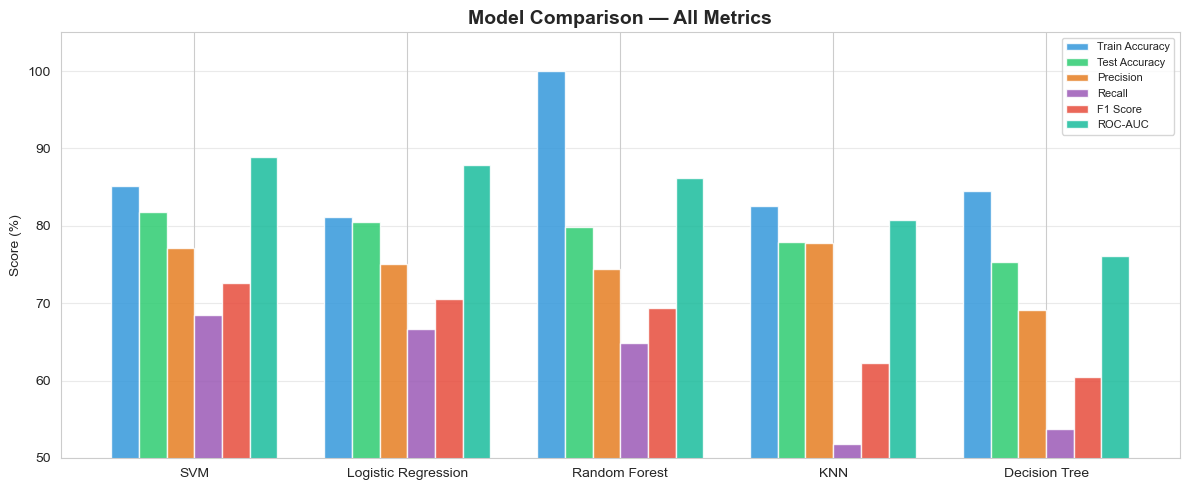

In [24]:
# Visual model comparison bar chart
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(results_df))
width = 0.13

metrics = ['Train Accuracy', 'Test Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
colors  = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6', '#e74c3c', '#1abc9c']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i*width, results_df[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(results_df['Model'], fontsize=10)
ax.set_ylabel('Score (%)')
ax.set_ylim(50, 105)
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

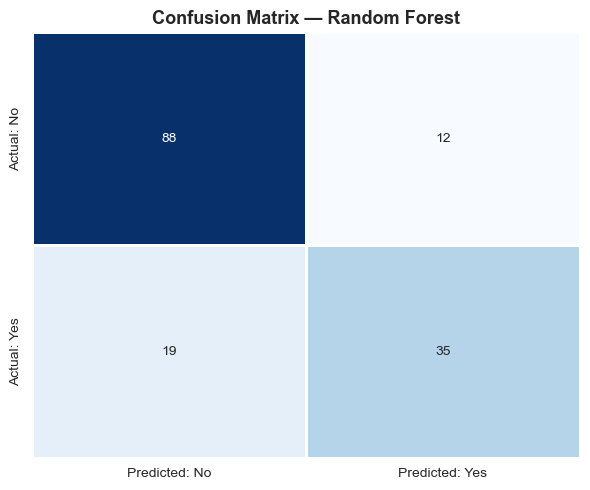

True Negatives  (Correctly predicted Non-Diabetic): 88
True Positives  (Correctly predicted Diabetic)    : 35
False Positives (Non-Diabetic predicted as Diabetic): 12 — False Alarm
False Negatives (Diabetic missed by model)         : 19 — Dangerous!

Out of 54 actual diabetic patients, model correctly identified 35 (64.8%)


In [25]:
# Confusion Matrix for Random Forest
y_pred_rf = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No',    'Actual: Yes'],
            linewidths=1, linecolor='white', cbar=False)
plt.title('Confusion Matrix — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Correctly predicted Non-Diabetic): {tn}")
print(f"True Positives  (Correctly predicted Diabetic)    : {tp}")
print(f"False Positives (Non-Diabetic predicted as Diabetic): {fp} — False Alarm")
print(f"False Negatives (Diabetic missed by model)         : {fn} — Dangerous!")
print(f"\nOut of {tp+fn} actual diabetic patients, model correctly identified {tp} ({tp/(tp+fn)*100:.1f}%)")

In [26]:
# Classification Report
print("Detailed Classification Report — Random Forest")
print("=" * 55)
print(classification_report(y_test, y_pred_rf,
      target_names=['Non-Diabetic', 'Diabetic']))

Detailed Classification Report — Random Forest
              precision    recall  f1-score   support

Non-Diabetic       0.82      0.88      0.85       100
    Diabetic       0.74      0.65      0.69        54

    accuracy                           0.80       154
   macro avg       0.78      0.76      0.77       154
weighted avg       0.80      0.80      0.80       154



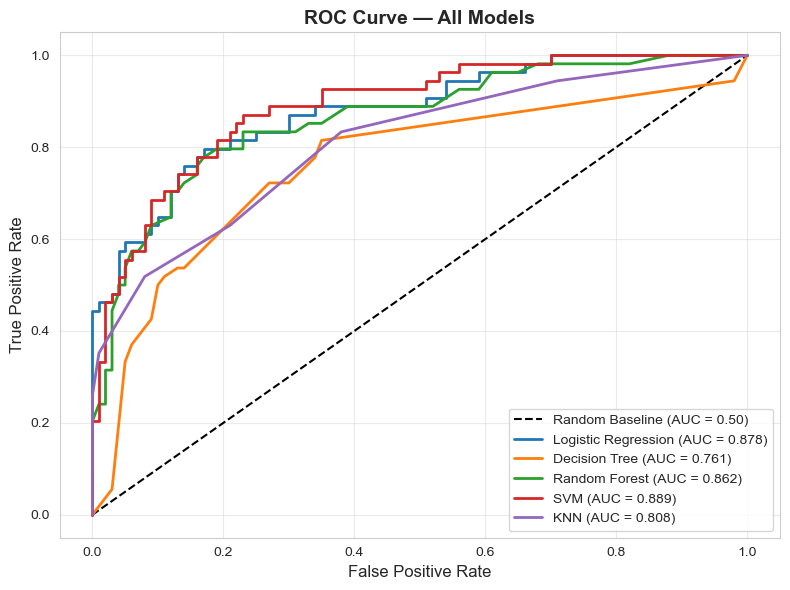

In [27]:
# ROC Curve — all models
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline (AUC = 0.50)')

for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

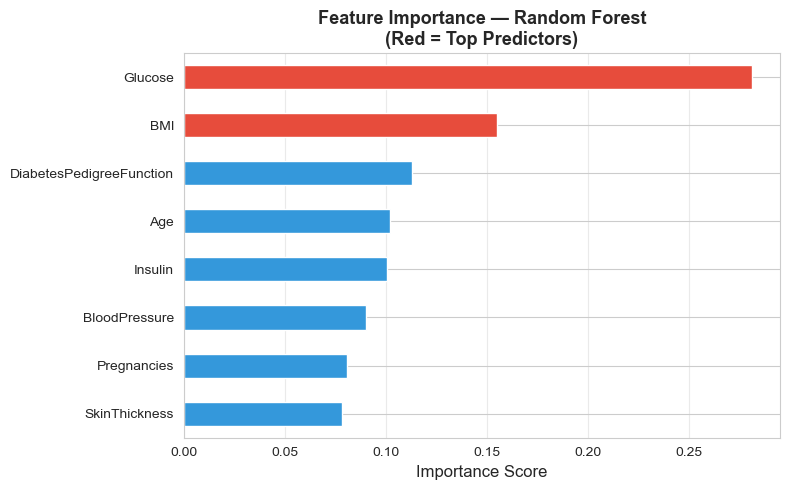

Feature Importance Ranking:
  1. Glucose                     : 0.2808  ████████████████████████████
  2. BMI                         : 0.1547  ███████████████
  3. DiabetesPedigreeFunction    : 0.1126  ███████████
  4. Age                         : 0.1021  ██████████
  5. Insulin                     : 0.1007  ██████████
  6. BloodPressure               : 0.0903  █████████
  7. Pregnancies                 : 0.0806  ████████
  8. SkinThickness               : 0.0783  ███████


In [29]:
## Feature Importance

feat_imp = pd.Series(rf.feature_importances_, index=features_list)
feat_imp = feat_imp.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
colors_bar = ['#e74c3c' if v > 0.13 else '#3498db' for v in feat_imp.values]
feat_imp.plot(kind='barh', color=colors_bar)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance — Random Forest\n(Red = Top Predictors)', fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

print("Feature Importance Ranking:")
for i, (feat, imp) in enumerate(feat_imp.sort_values(ascending=False).items(), 1):
    bar = '█' * int(imp * 100)
    print(f"  {i}. {feat:<28}: {imp:.4f}  {bar}")